In [3]:
import pandas as pd

csv_path = "https://drive.google.com/uc?export=download&id=1qBfxhp1kCyBgDFTOiDETS1vT9yQi36sx"
df = pd.read_csv(csv_path)
df

,Movie Name,Storyline,Cleaned_Storyline
0,The Substance,A fading celebrity takes a black-market drug: ...,fading celebrity takes blackmarket drug cellre...
1,The Life of Chuck,"A life-affirming, genre-bending story about th...",lifeaffirming genrebending story three chapter...
2,Bone Lake,A couple's vacation at a secluded estate is up...,couples vacation secluded estate upended theyr...
3,Anora,A young stripper from Brooklyn meets and impul...,young stripper brooklyn meets impulsively marr...
4,Eden,Based on a factual account of a group of outsi...,based factual account group outsiders settle r...
...,...,...,...
5094,Juni,Partha is a young chef in Bangalore who falls ...,partha young chef bangalore falls juni regular...
5095,Timing,Two young ex-lovers randomly reconnect.,two young exlovers randomly reconnect
5096,Lakatabu,When a man begins to use his powers for crimin...,man begins use powers criminal activities thre...
5097,Emakku Thozhil Romance,Assistant director Umashankar falls for Leo. M...,assistant director umashankar falls leo misund...


In [4]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
import pandas as pd
import string
import nltk
import os
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Ensure required NLTK resources are available
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Read the dataset from the provided URL
csv_path = "https://drive.google.com/uc?export=download&id=1qBfxhp1kCyBgDFTOiDETS1vT9yQi36sx"
df = pd.read_csv(csv_path).fillna('')
df = df.drop_duplicates(subset=['Movie Name']).reset_index(drop=True)

clean_storylines = []
stop_words = set(stopwords.words('english'))

# Clean each storyline safely
for text in df['Cleaned_Storyline']:
    text_str = str(text)
    if not text_str.strip():
        clean_storylines.append("")
        continue

    text_str = " ".join(text_str.lower().split())
    tokens = word_tokenize(text_str)
    filtered = [w for w in tokens if w not in stop_words and w not in string.punctuation]
    clean_storylines.append(" ".join(filtered))

# Replace the column with cleaned text
df['Cleaned_Storyline'] = clean_storylines

# Save to a writable local folder
output_dir = os.path.join(os.getcwd(), "output")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "IMDb_2024_Cleaned_Processed.csv")
df.to_csv(output_path, index=False)

print(f"Successfully processed and written to: {output_path}")
print("\n--- Quick Verification Check ---")
print(df[['Movie Name', 'Cleaned_Storyline']].head(3))

Successfully processed and written to: c:\Users\Acer\OneDrive\Documents\IMDB\output\output\IMDb_2024_Cleaned_Processed.csv

--- Quick Verification Check ---
          Movie Name                                  Cleaned_Storyline
0      The Substance  fading celebrity takes blackmarket drug cellre...
1  The Life of Chuck  lifeaffirming genrebending story three chapter...
2          Bone Lake  couples vacation secluded estate upended theyr...


In [6]:
pip install pyspellchecker

Note: you may need to restart the kernel to use updated packages.


error: externally-managed-environment

× This environment is externally managed
╰─> This Python installation is managed by uv and should not be modified.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


In [7]:
import pandas as pd
import string
import nltk
import os
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK parts
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Initialize tools
lemmatizer = WordNetLemmatizer()

# Read the dataset from the provided URL
csv_path = "https://drive.google.com/uc?export=download&id=1qBfxhp1kCyBgDFTOiDETS1vT9yQi36sx"
df = pd.read_csv(csv_path).fillna('')
df = df.drop_duplicates(subset=['Movie Name']).reset_index(drop=True)

clean_storylines = []
stop_words = set(stopwords.words('english'))

print("Starting text cleaning and lemmatization (this may take a moment)...")

for text in df['Cleaned_Storyline']:
    text_str = " ".join(str(text).lower().split())
    if not text_str.strip():
        clean_storylines.append("")
        continue

    tokens = word_tokenize(text_str)

    filtered = []
    for w in tokens:
        # Skip stopwords and punctuation
        if w in stop_words or w in string.punctuation:
            continue

        # Directly lemmatize the word (No spellcheck)
        lemma_w = lemmatizer.lemmatize(w)
        filtered.append(lemma_w)

    clean_storylines.append(" ".join(filtered))

df['Cleaned_Storyline'] = clean_storylines

output_dir = os.path.join(os.getcwd(), "output")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "IMDb_2024_Cleaned_Processed.csv")
df.to_csv(output_path, index=False)

print(f"NLTK Processing Complete! Saved to: {output_path}")

Starting text cleaning and lemmatization (this may take a moment)...
NLTK Processing Complete! Saved to: c:\Users\Acer\OneDrive\Documents\IMDB\output\output\IMDb_2024_Cleaned_Processed.csv


In [8]:
import os
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load the cleaned dataset from the local output folder
output_path = os.path.join(os.getcwd(), "output", "IMDb_2024_Cleaned_Processed.csv")
df = pd.read_csv(output_path).fillna('')

# 2. Fit the TF-IDF Vectorizer on your processed storylines
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['Cleaned_Storyline'])

# 3. Calculate the Cosine Similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# 4. Create a quick index map for looking up movie row numbers instantly
movie_indices = pd.Series(df.index, index=df['Movie Name'].str.lower().str.strip()).drop_duplicates()

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print("Cosine Similarity matrix successfully calculated!")

TF-IDF Matrix Shape: (5059, 16258)
Cosine Similarity matrix successfully calculated!


In [15]:
import numpy as np
CUSTOM_PLOT_INPUT ="After a group of criminals kidnap the ballerina daughter of a powerful underworld figure, they retreat to an isolated mansion, unaware that they're locked inside with no normal little girl."
TOP_N = 5
# =====================================================================

# 1. Clean the user text exactly like your dataset (lowercase, space stripped)
clean_custom_text = " ".join(CUSTOM_PLOT_INPUT.lower().split())

# 2. Convert the custom text into a math vector using the existing TF-IDF tool
# (We use .transform() here, NOT .fit_transform())
custom_vector = tfidf.transform([clean_custom_text])

# 3. Calculate cosine similarity between your custom vector and all movies in the dataset
# This returns an array of matching scores
custom_scores = cosine_similarity(custom_vector, tfidf_matrix).flatten()

# 4. Map, sort, and slice the top 5 highest matching rows
ranked_indices = np.argsort(custom_scores)[::-1][:TOP_N]
top_scores = custom_scores[ranked_indices]

# 5. Extract findings into a clean dataframe
custom_recs_df = df[['Movie Name', 'Storyline']].iloc[ranked_indices].copy()
custom_recs_df['Match Score (%)'] = [round(score * 100, 1) for score in top_scores]

# --- Print Text Results ---
print(f"🔮 Top {TOP_N} Movie Matches for your input plot:\n")
for i, row in custom_recs_df.reset_index(drop=True).iterrows():
    print(f"📌 {i+1}. {row['Movie Name']} (Match Score: {row['Match Score (%)']}%)")
    print(f"   Plot: {row['Storyline']}\n" + "-"*60)

🔮 Top 5 Movie Matches for your input plot:

📌 1. Abigail (Match Score: 95.5%)
   Plot: After a group of criminals kidnap the ballerina daughter of a powerful underworld figure, they retreat to an isolated mansion, unaware that they're locked inside with no normal little girl.
------------------------------------------------------------
📌 2. Bleeding (Match Score: 17.1%)
   Plot: In a world where vampire blood is harvested as a drug, two desperate teenagers on the run from a vicious dealer break into an empty house and find a sleeping girl locked inside.
------------------------------------------------------------
📌 3. Bauk (Match Score: 14.3%)
   Plot: Sava, her mother and little brother live in a skyscraper in Belgrade. That normal life is interrupted by the bombing of Serbia. A shelter becomes his new home and Milica, the daughter of the priest he is in love with, leaves the country.
------------------------------------------------------------
📌 4. 1978 (Match Score: 13.4%)
   Plot: 

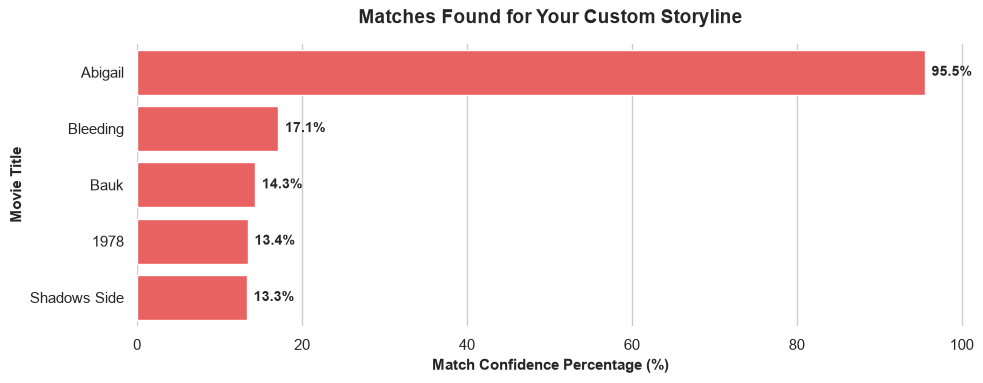

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Sort descending for the bar chart look
plot_custom_data = custom_recs_df.sort_values(by='Match Score (%)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))

sns.barplot(
    data=plot_custom_data,
    x='Match Score (%)',
    y='Movie Name',
    ax=ax,
    color="#ff4b4b"
)

ax.set_title("Matches Found for Your Custom Storyline", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Match Confidence Percentage (%)", fontsize=11, fontweight='bold')
ax.set_ylabel("Movie Title", fontsize=11, fontweight='bold')
sns.despine(left=True, bottom=True)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()